# Dijkstra: A Self-Learning Demo

## Why Dijkstra?

Dijkstra's algorithm is the weighted version of shortest-path search.
It is the right choice when different cells or edges have different costs, but all costs stay non-negative.

In this notebook, you will:

1. Build a small weighted grid.
2. Implement Dijkstra with a priority queue.
3. Visualize the resulting minimum-cost path.
4. Compare a fixed example with a few interactive settings.

## Dijkstra Method Essentials

When reading the code, keep these ideas in mind:

- **Priority queue**: always expands the lowest-cost frontier node first.
- **Distance map**: stores the best known cost to each cell.
- **Relaxation**: updates a neighbor when a cheaper route is found.
- **Parent map**: remembers how to rebuild the final path.

## 1) Helper Functions

The first code cell defines the reusable pieces.

Pay special attention to the priority queue and the distance dictionary. Those are the heart of Dijkstra's algorithm.

In [1]:
from heapq import heappop, heappush
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

Point = Tuple[int, int]


def neighbors4(cell: Point, shape: Tuple[int, int]) -> List[Point]:
    r, c = cell
    rows, cols = shape
    out: List[Point] = []
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < cols:
            out.append((nr, nc))
    return out


def dijkstra_grid(cost_grid: np.ndarray, start: Point, goal: Point) -> Optional[List[Point]]:
    if cost_grid[start] < 0 or cost_grid[goal] < 0:
        return None

    rows, cols = cost_grid.shape
    dist: Dict[Point, float] = {start: 0.0}
    parent: Dict[Point, Optional[Point]] = {start: None}
    heap: List[Tuple[float, Point]] = [(0.0, start)]

    while heap:
        cur_cost, cur = heappop(heap)
        if cur == goal:
            break
        if cur_cost > dist.get(cur, float('inf')):
            continue

        for nxt in neighbors4(cur, (rows, cols)):
            cell_cost = cost_grid[nxt]
            if cell_cost < 0:
                continue
            new_cost = cur_cost + float(cell_cost)
            if new_cost < dist.get(nxt, float('inf')):
                dist[nxt] = new_cost
                parent[nxt] = cur
                heappush(heap, (new_cost, nxt))

    if goal not in parent:
        return None

    path: List[Point] = []
    cur: Optional[Point] = goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path


def draw_cost_grid(cost_grid: np.ndarray, start: Point, goal: Point, path: Optional[List[Point]], title: str = 'Dijkstra on Weighted Grid') -> None:
    vis = np.zeros((*cost_grid.shape, 3), dtype=float)
    finite_mask = cost_grid >= 0
    max_cost = float(cost_grid[finite_mask].max()) if finite_mask.any() else 1.0

    for r in range(cost_grid.shape[0]):
        for c in range(cost_grid.shape[1]):
            value = cost_grid[r, c]
            if value < 0:
                vis[r, c] = [0.0, 0.0, 0.0]
            else:
                shade = 1.0 - (value / max_cost if max_cost > 0 else 0.0) * 0.45
                vis[r, c] = [shade, shade, shade]

    if path is not None:
        for r, c in path:
            vis[r, c] = [0.2, 0.5, 0.95]

    vis[start] = [0.1, 0.8, 0.2]
    vis[goal] = [0.9, 0.2, 0.2]

    plt.figure(figsize=(6, 6))
    plt.imshow(vis, interpolation='nearest')
    plt.title(title)
    plt.xticks(range(cost_grid.shape[1]))
    plt.yticks(range(cost_grid.shape[0]))
    plt.grid(color='lightgray', linewidth=0.5)
    plt.show()

## 2) Build the Cost Map

This cell defines the weighted grid, the start cell, and the goal cell.

Use `-1` for obstacles and positive numbers for traversal cost.

In [ ]:
# Weighted grid: -1 means obstacle, non-negative numbers mean traversal cost
cost_grid = np.array(
    [
        [1, 1, 1, -1, 2, 2, 2],
        [1, 3, 1, -1, 2, -1, 2],
        [1, 3, 1, 1, 1, -1, 2],
        [1, -1, -1, -1, 1, -1, 2],
        [1, 1, 2, 2, 1, 1, 2],
        [1, -1, 2, 3, 3, -1, 2],
        [1, 1, 1, -1, 1, 1, 1],
    ],
    dtype=float,
)

start = (0, 0)
goal = (6, 6)

print('Cost map ready.')
print(f'Start: {start}')
print(f'Goal: {goal}')
print('Positive numbers are traversal costs; -1 means obstacle.')

Cost map ready.
Start: (0, 0)
Goal: (6, 6)
Positive numbers are traversal costs; -1 means obstacle.


## 3) Run Dijkstra on the Map

Now that the map is ready, we can compute the minimum-cost path and draw the result.

Path found: True
Path cost: 14.0
Path nodes: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4), (4, 5), (4, 6), (5, 6), (6, 6)]


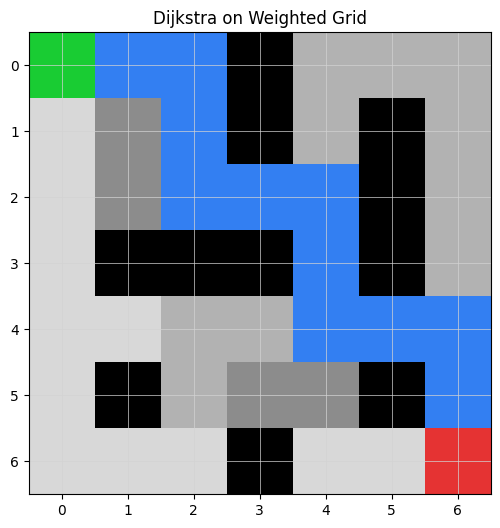

In [3]:
path = dijkstra_grid(cost_grid, start, goal)

print(f'Path found: {path is not None}')
if path is not None:
    path_cost = sum(cost_grid[cell] for cell in path[1:])
    print(f'Path cost: {path_cost}')
    print(f'Path nodes: {path}')
else:
    print('No feasible path found.')

draw_cost_grid(cost_grid, start, goal, path)

## 4) Explore Interactively

Use the controls below to switch between a few cost maps and see how the minimum-cost path changes.

In [4]:
map_cases = {
    'Balanced Costs': {
        'grid': np.array([
            [1, 1, 1, -1, 2, 2, 2],
            [1, 3, 1, -1, 2, -1, 2],
            [1, 3, 1, 1, 1, -1, 2],
            [1, -1, -1, -1, 1, -1, 2],
            [1, 1, 2, 2, 1, 1, 2],
            [1, -1, 2, 3, 3, -1, 2],
            [1, 1, 1, -1, 1, 1, 1],
        ], dtype=float),
        'start': (0, 0),
        'goal': (6, 6),
    },
    'High-Cost Center': {
        'grid': np.array([
            [1, 1, 1, 1, 1, 1, 1],
            [1, 5, 5, 5, 5, 5, 1],
            [1, 5, -1, -1, -1, 5, 1],
            [1, 5, -1, 1, -1, 5, 1],
            [1, 5, -1, -1, -1, 5, 1],
            [1, 5, 5, 5, 5, 5, 1],
            [1, 1, 1, 1, 1, 1, 1],
        ], dtype=float),
        'start': (0, 0),
        'goal': (6, 6),
    },
}

map_selector = widgets.Dropdown(
    options=list(map_cases.keys()),
    value='Balanced Costs',
    description='Map',
)

output = widgets.Output()

def update_view(*_args):
    case = map_cases[map_selector.value]
    grid_local = case['grid']
    start_local = case['start']
    goal_local = case['goal']

    with output:
        output.clear_output(wait=True)
        path_local = dijkstra_grid(grid_local, start_local, goal_local)
        print(f'Path found: {path_local is not None}')
        if path_local is not None:
            path_cost_local = sum(grid_local[cell] for cell in path_local[1:])
            print(f'Path cost: {path_cost_local}')
        else:
            print('No feasible path found.')
        draw_cost_grid(grid_local, start_local, goal_local, path_local, title='Dijkstra interactive view')

map_selector.observe(update_view, names='value')
display(widgets.VBox([map_selector, output]))
update_view()

## What to Try Next

- Change some terrain costs and see whether the path shifts around them.
- Add or remove obstacles.
- Compare the result with BFS on a uniform-cost grid.